# **Task 1**

## Load Libraries

In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Load Datasets
8 student datasets for VLE analysis are available from OULAD dataset. (Found at https://raw.githubusercontent.com/vjcalling/OULAD-data-analysis-EDA-/master/data/raw/)

In [3]:
studentVle_df1 = pd.read_csv('https://raw.githubusercontent.com/vjcalling/OULAD-data-analysis-EDA-/master/data/raw/studentVle_0.csv')
studentVle_df2 = pd.read_csv('https://raw.githubusercontent.com/vjcalling/OULAD-data-analysis-EDA-/master/data/raw/studentVle_1.csv')
studentVle_df3 = pd.read_csv('https://raw.githubusercontent.com/vjcalling/OULAD-data-analysis-EDA-/master/data/raw/studentVle_2.csv')
studentVle_df4 = pd.read_csv('https://raw.githubusercontent.com/vjcalling/OULAD-data-analysis-EDA-/master/data/raw/studentVle_3.csv')
studentVle_df5 = pd.read_csv('https://raw.githubusercontent.com/vjcalling/OULAD-data-analysis-EDA-/master/data/raw/studentVle_4.csv')
studentVle_df6 = pd.read_csv('https://raw.githubusercontent.com/vjcalling/OULAD-data-analysis-EDA-/master/data/raw/studentVle_5.csv')
studentVle_df7 = pd.read_csv('https://raw.githubusercontent.com/vjcalling/OULAD-data-analysis-EDA-/master/data/raw/studentVle_6.csv')
studentVle_df8 = pd.read_csv('https://raw.githubusercontent.com/vjcalling/OULAD-data-analysis-EDA-/master/data/raw/studentVle_7.csv')          

studentVle_df = pd.concat([studentVle_df1,studentVle_df2, studentVle_df3, studentVle_df4, studentVle_df5, studentVle_df6, studentVle_df7, studentVle_df8])
studentVle_df.head()

,Unnamed: 0,code_module,code_presentation,id_student,id_site,date,sum_click
0,0,AAA,2013J,28400,546652,-10,4
1,1,AAA,2013J,28400,546652,-10,1
2,2,AAA,2013J,28400,546652,-10,1
3,3,AAA,2013J,28400,546614,-10,11
4,4,AAA,2013J,28400,546714,-10,1


In [4]:
studentVle_df = studentVle_df[studentVle_df['date'] >= 0]    # Filter out negative dates
vle = pd.read_csv('https://raw.githubusercontent.com/vjcalling/OULAD-data-analysis-EDA-/master/data/raw/vle.csv')
studentVle_df['week'] = studentVle_df['date'] // 7

## Behavioral features

### 1.Weekly Clicks
Gathers total clicks over a week for a particular course in a particular semester

In [5]:
weekly_clicks = studentVle_df.groupby(
    ['id_student', 'code_presentation', 'code_module', 'week',
]
)['sum_click'].sum().reset_index()

print(weekly_clicks)
weekly_clicks.to_csv("weekly_clicks.csv", index=False)

        id_student code_presentation code_module  week  sum_click
0             6516             2014J         AAA     0        229
1             6516             2014J         AAA     1         42
2             6516             2014J         AAA     2         79
3             6516             2014J         AAA     3        193
4             6516             2014J         AAA     4         69
...            ...               ...         ...   ...        ...
579433     2698588             2014J         BBB    32         13
579434     2698588             2014J         BBB    33        147
579435     2698588             2014J         BBB    34         12
579436     2698588             2014J         BBB    35          7
579437     2698588             2014J         BBB    36          1

[579438 rows x 5 columns]


### 2.Weekly Active Days
Tells the number of days the student opens the course in a week

In [6]:
weekly_days = studentVle_df.groupby(
    ['id_student','code_presentation', 'code_module', 'week',]
)['date'].nunique().reset_index()

weekly_days.rename(columns={'date':'active_days'}, inplace=True)

print(weekly_days)

        id_student code_presentation code_module  week  active_days
0             6516             2014J         AAA     0            6
1             6516             2014J         AAA     1            4
2             6516             2014J         AAA     2            5
3             6516             2014J         AAA     3            3
4             6516             2014J         AAA     4            4
...            ...               ...         ...   ...          ...
579433     2698588             2014J         BBB    32            1
579434     2698588             2014J         BBB    33            6
579435     2698588             2014J         BBB    34            3
579436     2698588             2014J         BBB    35            2
579437     2698588             2014J         BBB    36            1

[579438 rows x 5 columns]


### 3.Weekly Activity Diversity
Tells the number of different sites visited by the student

In [7]:
merged = studentVle_df.merge(
    vle[['id_site','activity_type']],
    on='id_site'
)
weekly_div = merged.groupby(
    ['id_student','code_presentation', 'code_module', 'week']
)['activity_type'].nunique().reset_index()

weekly_div.rename(
    columns={'activity_type':'activity_diversity'},
    inplace=True
)

print(weekly_div)

        id_student code_presentation code_module  week  activity_diversity
0             6516             2014J         AAA     0                   6
1             6516             2014J         AAA     1                   4
2             6516             2014J         AAA     2                   5
3             6516             2014J         AAA     3                   4
4             6516             2014J         AAA     4                   4
...            ...               ...         ...   ...                 ...
579433     2698588             2014J         BBB    32                   5
579434     2698588             2014J         BBB    33                   6
579435     2698588             2014J         BBB    34                   3
579436     2698588             2014J         BBB    35                   3
579437     2698588             2014J         BBB    36                   1

[579438 rows x 5 columns]


### 4.Weekly Assessment Score

In [8]:
studentAssessment = pd.read_csv('https://raw.githubusercontent.com/vjcalling/OULAD-data-analysis-EDA-/master/data/raw/studentAssessment.csv')   
studentAssessment['week'] = studentAssessment['date_submitted'] // 7

weekly_assess = studentAssessment.groupby(
    ['id_student','week']
)['score'].mean().reset_index()

print(weekly_assess)

        id_student  week  score
0             6516     2   60.0
1             6516     7   48.0
2             6516    16   63.0
3             6516    23   61.0
4             6516    30   77.0
...            ...   ...    ...
148635     2698588     2  100.0
148636     2698588     7   85.0
148637     2698588    15   87.0
148638     2698588    21   95.0
148639     2698588    28   95.0

[148640 rows x 3 columns]


### 5.Weekly Consistency
This parameter tells that within a given week, how evenly was the student active across different days. This works by computing standard deviation of the number of clicks on each day within one week. Higher the standard deviation, lesser is the consistency and vice-versa.

In [9]:
daily = studentVle_df.groupby(
    ['id_student','code_module','code_presentation','week','date']
)['sum_click'].sum().reset_index()

weekly_std = daily.groupby(
    ['id_student','code_module','code_presentation','week']
)['sum_click'].std().reset_index()

weekly_std.rename(
    columns={'sum_click':'consistency'},
    inplace=True
)

print(weekly_std)

        id_student code_module code_presentation  week  consistency
0             6516         AAA             2014J     0    24.136418
1             6516         AAA             2014J     1     8.185353
2             6516         AAA             2014J     2    13.479614
3             6516         AAA             2014J     3    70.613974
4             6516         AAA             2014J     4    15.564382
...            ...         ...               ...   ...          ...
579433     2698588         BBB             2014J    32          NaN
579434     2698588         BBB             2014J    33    28.190424
579435     2698588         BBB             2014J    34     1.732051
579436     2698588         BBB             2014J    35     2.121320
579437     2698588         BBB             2014J    36          NaN

[579438 rows x 5 columns]


### Dynamic Score

Dynamic score is a weighted sum of the first four parameters defined namely Weekly Clicks, Weekly Active Days, Weekly Activity and Weekly assessment score. Its value keeps updating every week. The coefficients for the each parameter in the weighted sum has been arbitrarily chosen to be 0.35, 0.25, 0.2, 0.2 respectively.

In [10]:
final = weekly_clicks.merge(weekly_days,on=['id_student','week']) \
                     .merge(weekly_div,on=['id_student','week']) \
                     .merge(weekly_assess,on=['id_student','week'],how='left')

# sort
final = final.sort_values(['id_student','week'])

# fill forward scores and fill remaining NaNs with 0
final['score'] = final.groupby('id_student')['score'].ffill()
final['score'] = final['score'].fillna(0)

In [11]:
final['dynamic_score'] = (
    0.35*final['sum_click'] +
    0.25*final['active_days'] +
    0.20*final['activity_diversity'] +
    0.20*final['score']
)
print(final[['id_student', 'week','dynamic_score']])

final.to_csv("final_output.csv", index=False)

        id_student  week  dynamic_score
0             6516     0          82.85
1             6516     1          16.50
2             6516     2          41.90
3             6516     3          81.10
4             6516     4          37.95
...            ...   ...            ...
818077     2698588    32          24.80
818078     2698588    33          73.15
818079     2698588    34          24.55
818080     2698588    35          22.55
818081     2698588    36          19.80

[818082 rows x 3 columns]


## Score Interpretation and Categories:
### 1) Consistent Performers

These students engage regularly and steadily.

Weekly pattern example:

Week:   1 2 3 4 5 6  

Clicks: 50 55 48 52 60 58

### 2) Last-Minute Sprinters

Inactive most of the time, huge spikes near deadlines.

Weekly pattern example:

Week:   1 2 3 4 5 6 

Clicks: 5 7 4 80 90 10

### 3) Drop-off Students

Start okay but gradually disappear.

Weekly pattern example:

Week:   1 2 3 4 5 6 

Clicks: 70 50 30 10 0 0

In [12]:
def classify_student(student_df):
    
    student_df = student_df.sort_values('week')
    scores = student_df['dynamic_score'].values
    weeks = student_df['week'].values
    
    avg_score = student_df['dynamic_score'].mean()
    max_score = student_df['dynamic_score'].max()
    
    # 1. Consistent Performer
    # low variation + decent average
    if (
        avg_score >= 30 and avg_score <= 70
        and student_df['dynamic_score'].std() <= 15
    ):
        return "Consistent Performer"
    
    
    # 2. Last-Minute Sprinter
    # low early scores, huge late spike
    early_weeks = student_df[student_df['week'] <= 25]['dynamic_score']
    late_weeks = student_df[student_df['week'] > 25]['dynamic_score']
    
    if (
        len(late_weeks) > 0
        and early_weeks.mean() < 40
        and late_weeks.mean() > 80
    ):
        return "Last-Minute Sprinter"
    
    
    # 3. Drop-off Student
    # high early engagement, low later

    early_weeks = student_df[student_df['week'] <= 10]['dynamic_score']
    late_weeks = student_df[student_df['week'] > 10]['dynamic_score']
    
    if (
        len(late_weeks) > 0
        and early_weeks.mean() > 50
        and late_weeks.mean() < 25
    ):
        return "Drop-off Student"
    
archetypes = final.groupby('id_student').apply(classify_student).reset_index()
archetypes.columns = ['id_student', 'archetype']

archetypes['archetype'].value_counts()

archetype
Consistent Performer    1083
Last-Minute Sprinter     303
Drop-off Student         157
Name: count, dtype: int64

### Plots for average consistent, last-minute sprinters and early drop-offs

        id_student archetype  week  active_days  sum_click  \
0             6516       NaN     0            6        229   
1             6516       NaN     1            4         42   
2             6516       NaN     2            5         79   
3             6516       NaN     3            3        193   
4             6516       NaN     4            4         69   
...            ...       ...   ...          ...        ...   
818077     2698588       NaN    32            1         13   
818078     2698588       NaN    33            6        147   
818079     2698588       NaN    34            3         12   
818080     2698588       NaN    35            2          7   
818081     2698588       NaN    36            1          1   

        activity_diversity  score  dynamic_score  
0                        6    0.0          82.85  
1                        4    0.0          16.50  
2                        5   60.0          41.90  
3                        4   60.0          81.10  


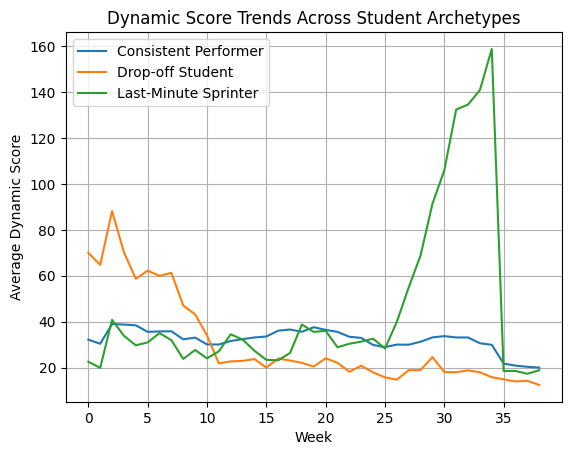

In [13]:
import matplotlib.pyplot as plt

archetypes = archetypes.merge(
    final[['id_student','week','active_days', 'sum_click', 'activity_diversity', 'score', 'dynamic_score']],
    on='id_student',
)
print(archetypes)

# average score per week for each archetype
avg_trend = archetypes.groupby(
    ['archetype', 'week']
)['dynamic_score'].mean().reset_index()

# plot each archetype separately on same graph
for archetype in avg_trend['archetype'].unique():
    temp = avg_trend[avg_trend['archetype'] == archetype]
    
    plt.plot(
        temp['week'],
        temp['dynamic_score'],
        label=archetype
    )

plt.xlabel("Week")
plt.ylabel("Average Dynamic Score")
plt.title("Dynamic Score Trends Across Student Archetypes")
plt.legend()
plt.grid(True)
plt.show()

# **Task 2**

## Inspect Outcome (pass/fail) CSV

In [14]:
studentInfo = pd.read_csv('https://raw.githubusercontent.com/vjcalling/OULAD-data-analysis-EDA-/master/data/raw/studentInfo.csv')
studentInfo.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


## Create Binary Target

In [16]:
# Withdrawn / Fail → 1      Pass / Distinction → 0
studentInfo['target'] = studentInfo['final_result'].apply(
    lambda x: 1 if x in ['Withdrawn', 'Fail'] else 0
)

## Build Features

Build a dataframe by combinining what exists in the 'final' dataframe and the new data from the 'studentInfo' dataframe regarding pass/fail status

In [27]:
# Consider only the first 5 weeks of data for modeling
early_data = archetypes[archetypes['week'] <= 5]

model_df = early_data.merge(
    studentInfo[['id_student','target']],
    on='id_student'
)

print(model_df)
model_df.to_csv("model_output.csv", index=False)

        id_student  week  active_days  sum_click  activity_diversity  score  \
0             6516     0            6        229                   6    0.0   
1             6516     1            4         42                   4    0.0   
2             6516     2            5         79                   5   60.0   
3             6516     3            3        193                   4   60.0   
4             6516     4            4         69                   4   60.0   
...            ...   ...          ...        ...                 ...    ...   
340776     2698588     0            2          9                   4    0.0   
340777     2698588     1            3         72                   7    0.0   
340778     2698588     2            1         18                   4  100.0   
340779     2698588     4            1          7                   2  100.0   
340780     2698588     5            1          2                   2  100.0   

        dynamic_score  target  
0               82.

## Logistic Regression

In [62]:
X = model_df.drop(['target'], axis=1)
y = model_df[['id_student', 'target']]

In [63]:
print(X)
print(y)

        id_student  week  active_days  sum_click  activity_diversity  score  \
0             6516     0            6        229                   6    0.0   
1             6516     1            4         42                   4    0.0   
2             6516     2            5         79                   5   60.0   
3             6516     3            3        193                   4   60.0   
4             6516     4            4         69                   4   60.0   
...            ...   ...          ...        ...                 ...    ...   
340776     2698588     0            2          9                   4    0.0   
340777     2698588     1            3         72                   7    0.0   
340778     2698588     2            1         18                   4  100.0   
340779     2698588     4            1          7                   2  100.0   
340780     2698588     5            1          2                   2  100.0   

        dynamic_score  
0               82.85  
1  

## Train Classifier

In [ ]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)

# Clean accidental duplicates first
X_clean = X.drop_duplicates(subset=['id_student', 'week'])

# Reshape: Turn the 6 "Long" rows into 1 "Wide" row
# This creates columns like active_days_w0, active_days_w1.
X_pivot = X_clean.pivot(index='id_student', columns='week', 
                        values=['active_days', 'sum_click', 'activity_diversity', 'score', 'dynamic_score'])

# Flatten the multi-level columns (e.g., ('sum_click', 0) becomes 'sum_click_w0')
X_pivot.columns = [f"{col[0]}_w{col[1]}" for col in X_pivot.columns]

# Handle missing data (if a student didn't log in during a specific week, fill with 0)
X_pivot = X_pivot.fillna(0)

# Align y with the pivoted X
# Ensure y is indexed by id_student or filtered to match the unique students in X_pivot
y_final = y.groupby('id_student').first() # Assumes target is the same for all weeks per student

In [ ]:
# SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X_pivot, y_final, test_size=0.2, random_state=42, stratify=y_final
)

In [171]:
# TRAIN MODEL
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,  # Smaller learning rate usually improves AUC
    max_depth=6,         # Depth of trees
    subsample=0.8,       # Prevent overfitting by using 80% of data per tree
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)


c:\Users\praty\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:53:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [172]:
# PREDICTIONS
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

In [173]:
# EVALUATION
print("--- Model Performance ---")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

--- Model Performance ---
Precision: 0.6941
Recall:    0.6462
F1 Score:  0.6693
ROC AUC:   0.7656

Confusion Matrix:
[[1994  677]
 [ 841 1536]]


# **Task 3**

I have designed a course-recommendation engine primarily for a student seeking for some courses that align with his interest in upcoming semesters, based on his current academic data.
## Option A: Content-based (using course metadata + student academic profile)


### Create Course Profile

In [82]:
course_profile = studentInfo.groupby(
    ['code_module']
).agg({
    'studied_credits':'mean',
    'num_of_prev_attempts':'mean'
}).reset_index()

### Add Pass Rate for each course

In [84]:
studentInfo['pass_rate'] = studentInfo['final_result'].apply(
    lambda x: 1 if x in ['Pass','Distinction'] else 0
)

pass_rate = studentInfo.groupby(
    ['code_module']
)['pass_rate'].mean().reset_index()

course_profile = course_profile.merge(
    pass_rate[['code_module','pass_rate']],
    on=['code_module']
)

print(course_profile)

  code_module  studied_credits  num_of_prev_attempts  pass_rate
0         AAA        84.438503              0.054813   0.709893
1         BBB        84.072576              0.211025   0.474649
2         CCC        77.487596              0.053000   0.378439
3         DDD        86.647800              0.248087   0.416135
4         EEE        65.436264              0.054192   0.562372
5         FFF        90.845143              0.202654   0.469982
6         GGG        34.459353              0.034333   0.597474


### Student Profile

In [89]:
student_profile = studentInfo.groupby('id_student').agg({
    'studied_credits':'mean',
    'num_of_prev_attempts':'mean'

})

### Add Pass Rate for each student

In [90]:
pass_rate = studentInfo.groupby(
    ['id_student']
)['pass_rate'].mean().reset_index()

student_profile =   student_profile.merge(
    pass_rate[['id_student','pass_rate']],
    on=['id_student']
)

print(student_profile)

       id_student  studied_credits  num_of_prev_attempts  pass_rate
0            3733             60.0                   0.0        0.0
1            6516             60.0                   0.0        1.0
2            8462             75.0                   0.5        0.0
3           11391            240.0                   0.0        1.0
4           23629             60.0                   2.0        0.0
...           ...              ...                   ...        ...
28780     2698591            180.0                   0.0        0.0
28781     2702660            240.0                   0.0        0.0
28782     2707979            120.0                   0.0        0.0
28783     2710343             60.0                   0.5        0.0
28784     2716795            120.0                   0.0        0.0

[28785 rows x 4 columns]


### Cosine Similarity
$$
\text{Cosine Similarity} = \frac{S \cdot C}{||S|| \, ||C||}
$$ 
Where:

- S = Student vector  
- C = Course vector 
- ||S|| = Magnitude of student vector  
- ||C|| = Magnitude of course vector  

Vectorise in the format [credits, prev_attempts, pass_rate] and find similarity

Let's say we want to find course recommendations for the first student in the student profile (id = 3733).

Create a vector for the student and drop the course and student ids out of the course and student profiles for similarity computation.

In [100]:
from sklearn.metrics.pairwise import cosine_similarity

student_vector = student_profile.iloc[0][[
    'studied_credits',
    'num_of_prev_attempts',
    'pass_rate'
]].values.reshape(1,-1)

course_matrix = course_profile[[
    'studied_credits',
    'num_of_prev_attempts',
    'pass_rate'
]]


Scale the vectors using a standard gaussian so as to reduce the effect of higher magnitude variables (Ex: high credits with low passing rate will be a less preffered option than low credits with high passing rate)

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

course_scaled = scaler.fit_transform(course_matrix)
student_scaled = scaler.transform(student_vector)

c:\Users\praty\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [102]:
similarities = cosine_similarity(student_scaled, course_scaled)

print(similarities)

[[-0.77532789 -0.00232684  0.93018347  0.20317523 -0.10936191  0.00466798
  -0.03533966]]


Thus, the top 3 suggested course for the student with id 3733 are CCC, DDD and FFF from above analysis.

## Cold Start Problem

Use age and higher education levels to decide the course-load.

Map age bands to credit preference

In [108]:
def preferred_credits(age_band):
    
    if age_band == '0-35':
        return 120   # can handle higher load
    
    elif age_band == '35-55':
        return 60    # moderate
    
    else:   # 55<=
        return 30    # lighter load

Map education level to pass-rate preference

In [107]:
def preferred_passrate(education):
    
    if education == 'HE Qualification':
        return 0.4
    
    elif education == 'A Level or Equivalent':
        return 0.5
    
    else:
        return 0.6

Recommendation function

In [ ]:
def cold_start_recommend(age_band, education):
    
    # choose preferred credits based on age
    credit_limit = preferred_credits(age_band)

    # choose preferred pass rate based on education
    min_pass = preferred_passrate(education)
    
    recommendations = course_profile[
        (course_profile['studied_credits'] <= credit_limit) &
        (course_profile['pass_rate'] >= min_pass)
    ]
    
    return recommendations.sort_values(
        by='pass_rate',
        ascending=False
    ).head(3)

Example

In [110]:
cold_start_recommend(
    age_band='0-35',
    education='HE Qualification'
)

,code_module,studied_credits,num_of_prev_attempts,pass_rate
0,AAA,84.438503,0.054813,0.709893
6,GGG,34.459353,0.034333,0.597474
4,EEE,65.436264,0.054192,0.562372


## Option B: Collaborative filtering (using interaction patterns of similar students)

Idea is to group students who have taken same courses in different/same semesters and choose any extra courses some other students among this lot have taken and recommend that to our student who wants to be recommended.

Interaction Matrix

In [153]:
# A student interacts with a course if he passes (distinction) and doesnt if he fails (withdraws)
studentInfo['interaction'] = studentInfo['final_result'].apply(
    lambda x: 1 if x in ['Pass','Distinction'] else 0
)

interaction_matrix = studentInfo.pivot_table(
    index='id_student',
    columns='code_module',
    values='interaction',
    fill_value=0
)

print(interaction_matrix)

code_module  AAA  BBB  CCC  DDD  EEE  FFF  GGG
id_student                                    
3733         0.0  0.0  0.0  0.0  0.0  0.0  0.0
6516         1.0  0.0  0.0  0.0  0.0  0.0  0.0
8462         0.0  0.0  0.0  0.0  0.0  0.0  0.0
11391        1.0  0.0  0.0  0.0  0.0  0.0  0.0
23629        0.0  0.0  0.0  0.0  0.0  0.0  0.0
...          ...  ...  ...  ...  ...  ...  ...
2698591      0.0  0.0  0.0  0.0  0.0  0.0  0.0
2702660      0.0  0.0  0.0  0.0  0.0  0.0  0.0
2707979      0.0  0.0  0.0  0.0  0.0  0.0  0.0
2710343      0.0  0.0  0.0  0.0  0.0  0.0  0.0
2716795      0.0  0.0  0.0  0.0  0.0  0.0  0.0

[28785 rows x 7 columns]


Find similar students using cosine similarity again.

In [154]:
student_similarity = cosine_similarity(
    interaction_matrix
)

# Convert to DataFrame for better readability
sim_df = pd.DataFrame(
    student_similarity,
    index=interaction_matrix.index,
    columns=interaction_matrix.index
)

Find similar students for one student

Example: student with id 3733

In [165]:
similar_students = sim_df[3733].sort_values(
    ascending=False
)

# Remove self and output top 5 similar students
similar_students = similar_students.iloc[1:6]

print(similar_students.index.tolist())

[6516, 8462, 11391, 23629, 23632]


Recommend top 3 courses.

This block looks at similar students, removes courses already taken by target student, keeps only courses they passed, counts most popular remaining courses and returns top 3 recommendations.

In [166]:
similar_ids = similar_students.index


taken = studentInfo[
    studentInfo['id_student'] == 3733
]['code_module'].unique()

top3 = (
    studentInfo[
        (studentInfo['id_student'].isin(similar_ids)) &
        (studentInfo['interaction'] == 1) &
        (~studentInfo['code_module'].isin(taken))
    ]
    ['code_module']
    .value_counts()
    .head(3)
)

print(top3.index.tolist())

['AAA']


Thus,we get a single course recommended based on this algorithm for student with id 3733.